In [ ]:
import os
import subprocess
import sys
import pypeit
import glob
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from pypeit.images.mosaic import Mosaic

In [10]:
raw_dir = "/Users/elliottburdett/research/neighborhood_watch/G-2025B-0505-V/raw"
working_dir = "/Users/elliottburdett/research/neighborhood_watch/G-2025B-0505-V/pypeit_reduction"
os.makedirs(working_dir, exist_ok=True)

In [11]:
fits_files = [f for f in os.listdir(raw_dir) if f.endswith('.fits')]
print(f"Found {len(fits_files)} FITS files in {raw_dir}:")
for f in fits_files:
    print(f" - {f}")

Found 70 FITS files in /Users/elliottburdett/research/neighborhood_watch/G-2025B-0505-V/raw:
 - S20250926S0077.fits
 - S20250928S0038.fits
 - S20250928S0043.fits
 - S20250928S0055.fits
 - S20250928S0130.fits
 - S20250927S0030.fits
 - S20250927S0026.fits
 - S20250926S0082.fits
 - S20250928S0034.fits
 - S20250928S0126.fits
 - S20250928S0059.fits
 - S20250927S0158.fits
 - S20250928S0058.fits
 - S20250928S0035.fits
 - S20250927S0027.fits
 - S20250927S0031.fits
 - S20250927S0154.fits
 - S20250923S0043.fits
 - S20250928S0054.fits
 - S20250928S0042.fits
 - S20250928S0039.fits
 - S20250928S0032.fits
 - S20250928S0049.fits
 - S20250925S0045.fits
 - S20250928S0028.fits
 - S20250928S0045.fits
 - S20250925S0049.fits
 - S20250928S0053.fits
 - S20250923S0044.fits
 - S20250927S0153.fits
 - S20250923S0045.fits
 - S20250928S0052.fits
 - S20250928S0044.fits
 - S20250925S0048.fits
 - bpm_20231214_gmos-s_Ham_44_full_12amp.fits
 - S20250928S0029.fits
 - S20250928S0048.fits
 - S20250928S0033.fits
 - S202509

In [12]:
instrument = "gemini_gmos_south_ham"

In [13]:
pypeit_file = os.path.join(working_dir, "longslit.pypeit")

In [14]:
cmd = [
"pypeit_setup",
"-r", raw_dir,
"-s", instrument,
"-d", working_dir,
"-c", "all"
]


print("Running:", " ".join(cmd))
subprocess.run(cmd, check=True)

Running: pypeit_setup -r /Users/elliottburdett/research/neighborhood_watch/G-2025B-0505-V/raw -s gemini_gmos_south_ham -d /Users/elliottburdett/research/neighborhood_watch/G-2025B-0505-V/pypeit_reduction -c all


    [INFO] - pypeitsetup.py:from_file_root:197 - Found 70 gemini_gmos_south_ham raw files.
    [INFO] - metadata.py:_build:206 - Building metadata for 70 files.
    [INFO] - metadata.py:_build:235 - Adding metadata for S20250923S0043.fits
    [INFO] - metadata.py:_build:235 - Adding metadata for S20250923S0044.fits
    [INFO] - metadata.py:_build:235 - Adding metadata for S20250923S0045.fits
    [INFO] - metadata.py:_build:235 - Adding metadata for S20250923S0046.fits
    [INFO] - metadata.py:_build:235 - Adding metadata for S20250923S0047.fits
    [INFO] - metadata.py:_build:235 - Adding metadata for S20250925S0045.fits
    [INFO] - metadata.py:_build:235 - Adding metadata for S20250925S0048.fits
    [INFO] - metadata.py:_build:235 - Adding metadata for S20250925S0049.fits
    [INFO] - metadata.py:_build:235 - Adding metadata for S20250925S0050.fits
    [INFO] - metadata.py:_build:235 - Adding metadata for S20250926S0077.fits
    [INFO] - metadata.py:_build:235 - Adding metadata for S

CompletedProcess(args=['pypeit_setup', '-r', '/Users/elliottburdett/research/neighborhood_watch/G-2025B-0505-V/raw', '-s', 'gemini_gmos_south_ham', '-d', '/Users/elliottburdett/research/neighborhood_watch/G-2025B-0505-V/pypeit_reduction', '-c', 'all'], returncode=0)

In [15]:
pypeit_files = glob.glob(working_dir + "/gemini_gmos_south_ham_*/**/*.pypeit", recursive=True)

for f in pypeit_files:
    print("\n====", f, "====\n")
    with open(f) as fh:
        for line in fh:
            if "science" in line.lower():
                print(line.strip())


==== /Users/elliottburdett/research/neighborhood_watch/G-2025B-0505-V/pypeit_reduction/gemini_gmos_south_ham_G/gemini_gmos_south_ham_G.pypeit ====

S20250927S0033.fits |                   science | 279.108126029167 |    -44.3102521125 |       LTT 7379 | R400+_G5325 | 1.5arcsec |     4,4 |  60945.04566302341 | 1.14200808072669 |     5.0 |  open1-6 |     863.0 | [1:128,1:1056] |   20.97 |     6
S20250928S0037.fits |                   science | 286.741833329167 | -63.9635000041667 | T1_dw1907m6357 | R400+_G5325 | 1.5arcsec |     4,4 | 60946.023707971195 | 1.23328248103481 |  1100.0 |  open1-6 |     863.0 | [1:128,1:1056] |   -0.46 |     6
S20250928S0038.fits |                   science | 286.741833329167 | -63.9635000041667 | T1_dw1907m6357 | R400+_G5325 | 1.5arcsec |     4,4 | 60946.036784359516 | 1.25138784275747 |  1100.0 |  open1-6 |     863.0 | [1:128,1:1056] |   -0.46 |     6
S20250928S0058.fits |                   science | 287.284291666667 | -63.6837444458333 |         T1_nuc | R

In [16]:
pypeit_files = glob.glob(working_dir + "/gemini_gmos_south_ham_*/*.pypeit")

for f in pypeit_files:
    print("Running:", f)
    subprocess.run(["run_pypeit", f, "-o"])

Running: /Users/elliottburdett/research/neighborhood_watch/G-2025B-0505-V/pypeit_reduction/gemini_gmos_south_ham_G/gemini_gmos_south_ham_G.pypeit


   [ERROR] - <frozen importlib._bootstrap>:parent:645 - KeyboardInterrupt
Traceback (most recent call last):
  File "/Users/elliottburdett/miniconda3/envs/dragonz/bin/run_pypeit", line 3, in <module>
    from pypeit.scripts.run_pypeit import RunPypeIt
  File "/Users/elliottburdett/miniconda3/envs/dragonz/lib/python3.12/site-packages/pypeit/scripts/__init__.py", line 7, in <module>
    from pypeit.scripts import arxiv_solution
  File "/Users/elliottburdett/miniconda3/envs/dragonz/lib/python3.12/site-packages/pypeit/scripts/arxiv_solution.py", line 12, in <module>
    from pypeit import inputfiles
  File "/Users/elliottburdett/miniconda3/envs/dragonz/lib/python3.12/site-packages/pypeit/inputfiles.py", line 22, in <module>
    from pypeit.spectrographs.util import load_spectrograph
  File "/Users/elliottburdett/miniconda3/envs/dragonz/lib/python3.12/site-packages/pypeit/spectrographs/__init__.py", line 14, in <module>
    from pypeit.spectrographs import keck_deimos
  File "/Users/elliott

KeyboardInterrupt: 

### Take a look at the products of reduction:

In [58]:
SCI_DIR = "/Users/elliottburdett/Desktop/Midgard/NOIRLab_REU/Science"

for f in sorted(os.listdir(SCI_DIR)):
    print(f)

spec1d_S20250927S0030-LTT7379_GMOS-S_20250927T010352.235.fits
spec1d_S20250927S0030-LTT7379_GMOS-S_20250927T010352.235.txt
spec1d_S20250927S0033-LTT7379_GMOS-S_20250927T010545.285.fits
spec1d_S20250927S0033-LTT7379_GMOS-S_20250927T010545.285.txt
spec1d_S20250928S0033-T1_dw1907m6357_GMOS-S_20250927T235517.219.fits
spec1d_S20250928S0033-T1_dw1907m6357_GMOS-S_20250927T235517.219.txt
spec1d_S20250928S0034-T1_dw1907m6357_GMOS-S_20250928T001358.902.fits
spec1d_S20250928S0034-T1_dw1907m6357_GMOS-S_20250928T001358.902.txt
spec1d_S20250928S0037-T1_dw1907m6357_GMOS-S_20250928T003408.369.fits
spec1d_S20250928S0037-T1_dw1907m6357_GMOS-S_20250928T003408.369.txt
spec1d_S20250928S0038-T1_dw1907m6357_GMOS-S_20250928T005258.169.fits
spec1d_S20250928S0038-T1_dw1907m6357_GMOS-S_20250928T005258.169.txt
spec1d_S20250928S0047-T1_nuc_GMOS-S_20250928T014205.235.fits
spec1d_S20250928S0047-T1_nuc_GMOS-S_20250928T014205.235.txt
spec1d_S20250928S0048-T1_nuc_GMOS-S_20250928T020046.769.fits
spec1d_S20250928S0048-T1

In [17]:
print("Contents of work directory:\n")
setup_dirs = sorted(glob.glob(os.path.join(working_dir, "gemini_gmos_south_ham_*")))
if len(setup_dirs) == 0:
    print("No setup directories found.")
else:
    for d in setup_dirs:
        name = os.path.basename(d)
        print(f"{name}/")
        sub = os.listdir(d)
        for s in sub:
            print(f"   └── {s}")
        print()

Contents of work directory:

gemini_gmos_south_ham_A/
   └── gemini_gmos_south_ham_A.calib
   └── gemini_gmos_south_ham_A.log
   └── gemini_gmos_south_ham_A_UTC_2026-02-11.par
   └── gemini_gmos_south_ham_A.pypeit

gemini_gmos_south_ham_B/
   └── gemini_gmos_south_ham_B.pypeit
   └── gemini_gmos_south_ham_B.log
   └── gemini_gmos_south_ham_B_UTC_2026-02-11.par
   └── gemini_gmos_south_ham_B.calib

gemini_gmos_south_ham_C/
   └── gemini_gmos_south_ham_C_UTC_2026-02-11.par
   └── gemini_gmos_south_ham_C.log
   └── gemini_gmos_south_ham_C.calib
   └── gemini_gmos_south_ham_C.pypeit

gemini_gmos_south_ham_D/
   └── gemini_gmos_south_ham_D.pypeit
   └── gemini_gmos_south_ham_D.log
   └── gemini_gmos_south_ham_D_UTC_2026-02-11.par
   └── gemini_gmos_south_ham_D.calib

gemini_gmos_south_ham_E/
   └── gemini_gmos_south_ham_E_UTC_2026-02-11.par
   └── gemini_gmos_south_ham_E.pypeit
   └── gemini_gmos_south_ham_E.log
   └── gemini_gmos_south_ham_E.calib

gemini_gmos_south_ham_F/
   └── gemini_gm

### Examine 2D Spectra

In [37]:
for f in spec2d_files:
    print(f)

spec2d_S20250927S0030-LTT7379_GMOS-S_20250927T010352.235.fits
spec2d_S20250927S0033-LTT7379_GMOS-S_20250927T010545.285.fits
spec2d_S20250928S0033-T1_dw1907m6357_GMOS-S_20250927T235517.219.fits
spec2d_S20250928S0034-T1_dw1907m6357_GMOS-S_20250928T001358.902.fits
spec2d_S20250928S0037-T1_dw1907m6357_GMOS-S_20250928T003408.369.fits
spec2d_S20250928S0038-T1_dw1907m6357_GMOS-S_20250928T005258.169.fits
spec2d_S20250928S0047-T1_nuc_GMOS-S_20250928T014205.235.fits
spec2d_S20250928S0048-T1_nuc_GMOS-S_20250928T020046.769.fits
spec2d_S20250928S0054-T1_nuc_GMOS-S_20250928T034102.352.fits
spec2d_S20250928S0055-T1_nuc_GMOS-S_20250928T035943.485.fits
spec2d_S20250928S0058-T1_nuc_GMOS-S_20250928T041950.202.fits
spec2d_S20250928S0061-T1_nuc_GMOS-S_20250928T043958.202.fits


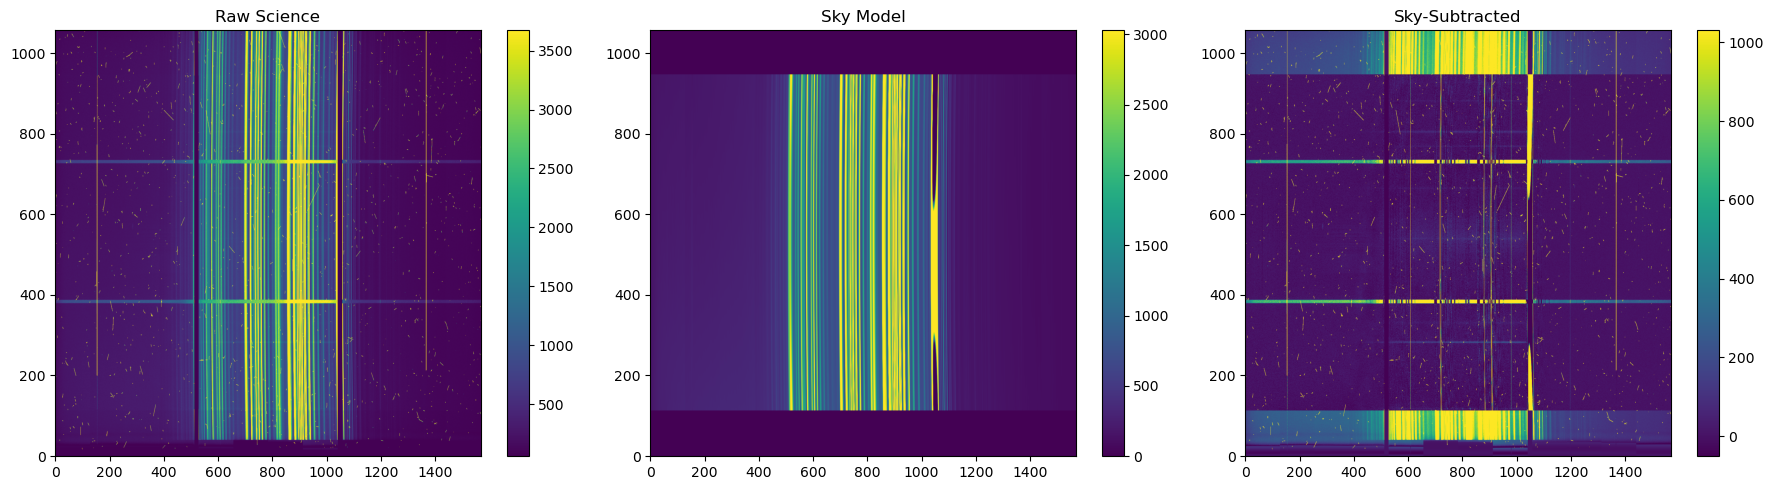

In [53]:
fname = os.path.join(SCI_DIR, spec2d_files[3])
hdul = fits.open(fname)

sci    = hdul['MSC01-SCIIMG'].data
sky    = hdul['MSC01-SKYMODEL'].data
obj    = hdul['MSC01-OBJMODEL'].data

sky_subtracted = sci - sky

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, img, title in zip(axes,
                           [sci, sky, sky_subtracted],
                           ['Raw Science', 'Sky Model', 'Sky-Subtracted']):
    vmin, vmax = np.percentile(img, [5, 95])
    ax.imshow(img.T, origin='lower', aspect='auto', vmin=vmin, vmax=vmax, cmap='viridis')
    ax.set_title(title)
    plt.colorbar(ax.images[0], ax=ax)

plt.tight_layout()
plt.show()

In [54]:
# before coadd to get rid of cosmic rays, evaluate sky subtraction quality:

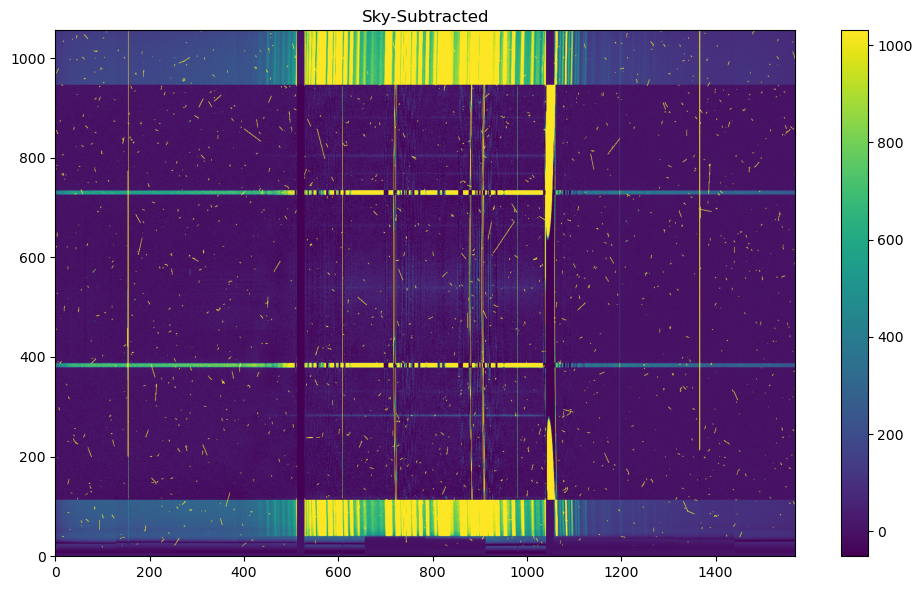

In [55]:
fname = os.path.join(SCI_DIR, spec2d_files[3])
hdul = fits.open(fname)

sci = hdul['MSC01-SCIIMG'].data
sky = hdul['MSC01-SKYMODEL'].data

sky_subtracted = sci - sky

vmin, vmax = np.percentile(sky_subtracted.T, [5, 95])

plt.figure(figsize=(10,6))
plt.imshow(sky_subtracted.T, origin='lower', aspect='auto', vmin=vmin, vmax=vmax, cmap='viridis')
plt.colorbar()
plt.title('Sky-Subtracted')
plt.tight_layout()
plt.show()

In [67]:
fname = os.path.join(SCI_DIR, spec2d_files[3])
hdul = fits.open(fname)

sci = hdul['MSC01-SCIIMG'].data
sky = hdul['MSC01-SKYMODEL'].data

residual = sci - sky

ny, nx = residual.shape
spatial_center = ny // 2
trace_half_width = 10

# Mask out object trace
mask = np.ones_like(residual, dtype=bool)
mask[spatial_center - trace_half_width : spatial_center + trace_half_width, :] = False

mask &= (sky != 0) # Also mask chip gaps (zero-valued columns in sky model)

sky_pixels     = sky[mask]
residual_pixels = residual[mask]

rms    = np.std(residual_pixels)
median = np.median(residual_pixels)
rel_rms = rms / np.median(sky_pixels)   # RMS as a fraction of median sky level

print(f"Sky residual median : {median:.4f} counts")
print(f"Sky residual RMS    : {rms:.4f} counts")
print(f"Relative RMS        : {rel_rms*100:.3f}%  (residual / median sky)")

hdul.close()

Sky residual median : 1.0469 counts
Sky residual RMS    : 9859.5195 counts
Relative RMS        : 3597.518%  (residual / median sky)


### Sky lines remain as a product of the Pypeit reduction.